# **Predicción del riesgo de estrés financiero en asalariados de la Comunidad de Madrid**
## **TFM - Máster de Data Science**
### *Análisis Exploratorio de Datos (EDA)*
---

**Input:** `data/02_silver/train_silver.csv` - conjunto de entrenamiento (80% de la muestra)  
**Población:** Asalariados en activo, Comunidad de Madrid, ECV 2025 (INE)  
**Target:** `estres_financiero_alto` - 0: sin estrés, 1: estrés financiero alto (≥2 de 5 condiciones)

---

### *Estructura del notebook*

| Sección | Contenido |
|---------|-----------|
| 0 | Setup y carga del train set |
| 1 | Auditoría inicial: tipos, nulos, cardinalidades |
| 2 | Distribución del target y desbalanceo |
| 3 | Variables demográficas |
| 4 | Variables laborales |
| 5 | Variables de renta |
| 6 | Variables de vivienda y cargas |
| 7 | Variables de privación material y salud |
| 8 | Variables de dinámica de ingresos |
| 9 | Indicadores de pobreza INE |
| 10 | Correlaciones y multicolinealidad |
| 11 | Análisis de nulos |
| 12 | Insights clave para la memoria del TFM |

> **Regla metodológica:** Todo el EDA se realiza exclusivamente sobre `train_silver.csv`.
> El test set permanece completamente oculto.


---
## **0. Setup y carga**


In [1]:
import os
os.chdir('..')

In [2]:
os.getcwd()

'c:\\Users\\sorim\\REPO_somm14\\EVOLVE\\tfm_project\\src'

In [3]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.ticker as mticker
from scipy import stats

from utils.functions_utils import tasa_estres_cat
from utils.constants_utils import PATH_TRAIN_SILVER, C0, C1
from utils.visualizations_utils import nulls_map, target_dis, target_age_dis, target_vs_var_demo_dis, target_vs_var_lab, target_vs_hours_exp

train = pd.read_csv(PATH_TRAIN_SILVER, low_memory=False)

# Subsets por clase
T0 = train[train['estres_financiero_alto'] == 0]
T1 = train[train['estres_financiero_alto'] == 1]

print(f'Train set cargado: {train.shape[0]:,} filas × {train.shape[1]} columnas')
print(f'Clase 0 (sin estrés): {len(T0):,}  |  Clase 1 (estrés alto): {len(T1):,}')

Train set cargado: 2,357 filas × 67 columnas
Clase 0 (sin estrés): 1,985  |  Clase 1 (estrés alto): 372


## **1. Auditoría inicial**


In [21]:
# Tipos de datos y cardinalidades
review = pd.DataFrame({
    'dtype':       train.dtypes,
    'n_nulos':     train.isnull().sum(),
    'pct_nulos':   (train.isnull().sum() / len(train) * 100).round(1),
    'n_unicos':    train.nunique(),
    'muestra':     train.iloc[0],
})

print(f'Variables numéricas:   {(review.dtype != "object").sum()}')
print(f'Variables categóricas: {(review.dtype == "object").sum()}')
print(f'Variables con nulos:   {(review.n_nulos > 0).sum()}')
print()
display(review)


Variables numéricas:   67
Variables categóricas: 0
Variables con nulos:   32



,dtype,n_nulos,pct_nulos,n_unicos,muestra
id_hogar,int64,0,0.0,1688,8468
id_persona,int64,0,0.0,2357,846801
region,str,0,0.0,1,ES30
grado_urbanizacion,str,0,0.0,3,Zona muy poblada
anio_nacimiento,int64,0,0.0,57,1981
...,...,...,...,...,...
arope_2030,str,0,0.0,2,No
renta_hogar_per_capita,float64,0,0.0,1688,117954.45
ratio_carga_vivienda,float64,22,0.9,2310,0.130685
precariedad_laboral,int64,0,0.0,2,0


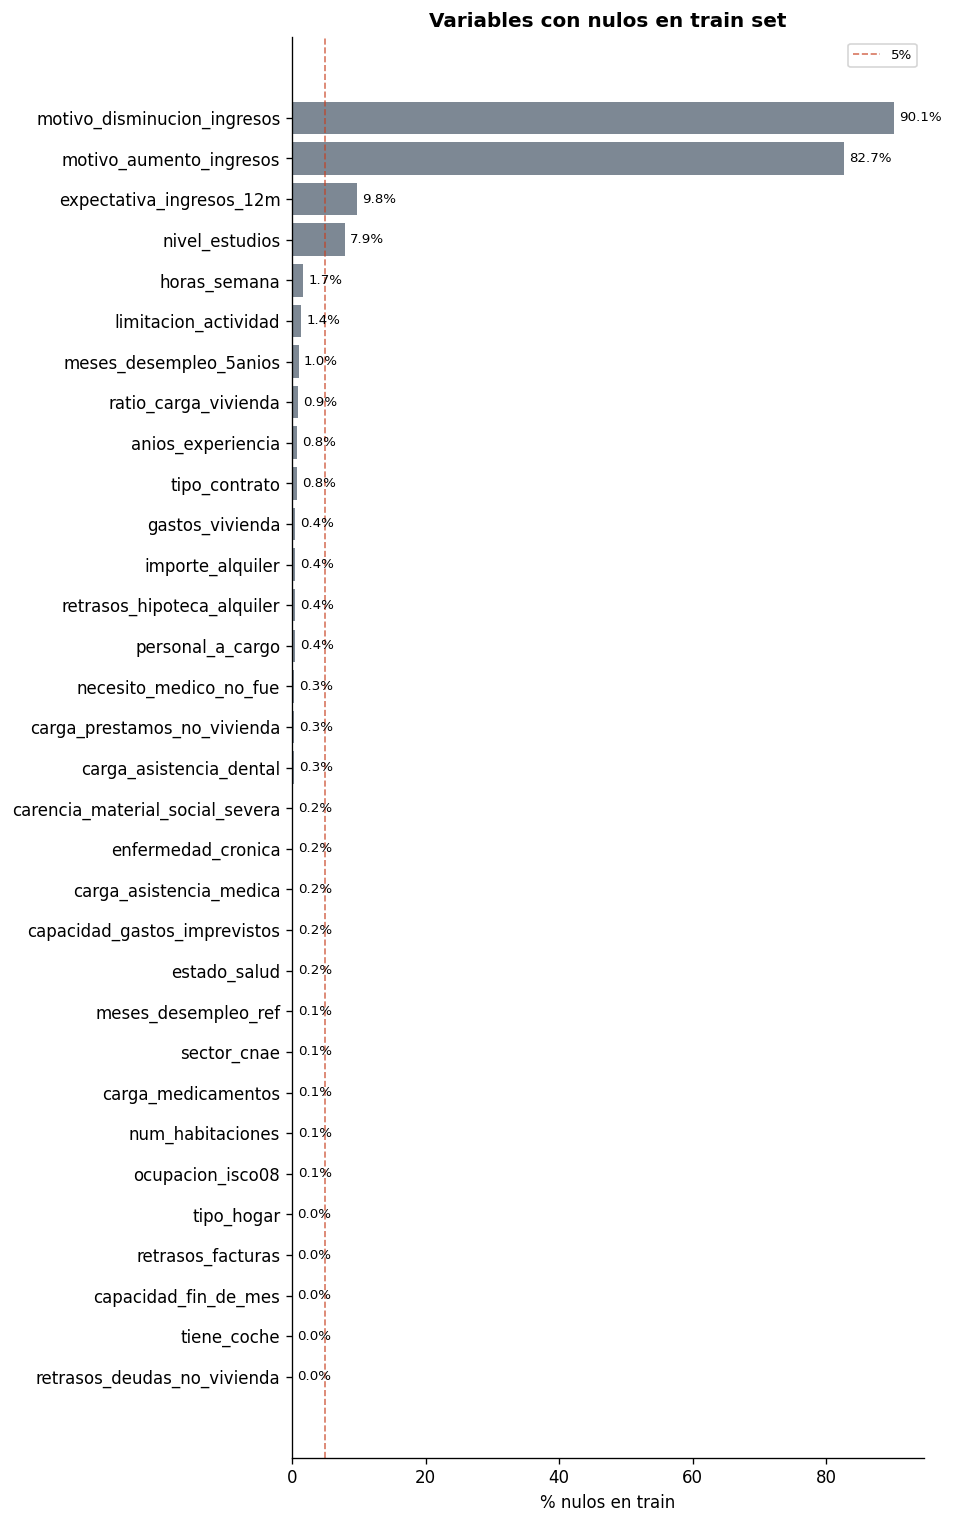

In [ ]:
# Mapa de nulos
nulos = train.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pct   = (nulos / len(train) * 100).round(1)

nulls_map(nulos, pct)

## **2. Distribución del target y desbalanceo**

El desbalanceo es una característica estructural del fenómeno, no un artefacto de muestreo.
Se usará una estrategia de modelado específica: `class_weight='balanced'` en el Pipeline.


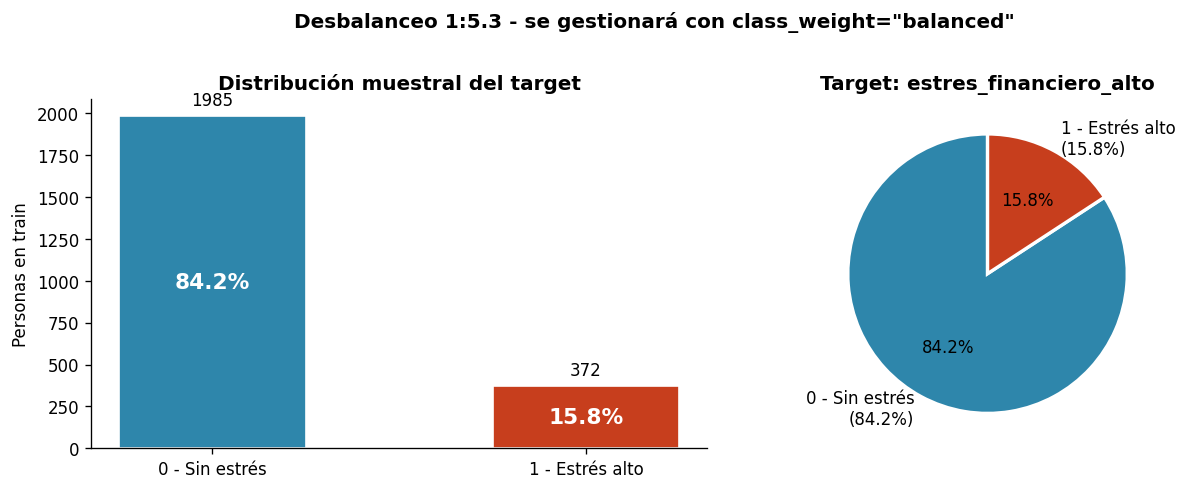

Clase 0: 1,985  (84.2%)
Clase 1: 372  (15.8%)
Ratio de desbalanceo: 1:5.3


In [5]:
vc  = train['estres_financiero_alto'].value_counts().sort_index()
n0, n1 = vc.get(0, 0), vc.get(1, 0)
total  = n0 + n1
target_dis(total, n0, n1)


## **3. Variables demográficas**

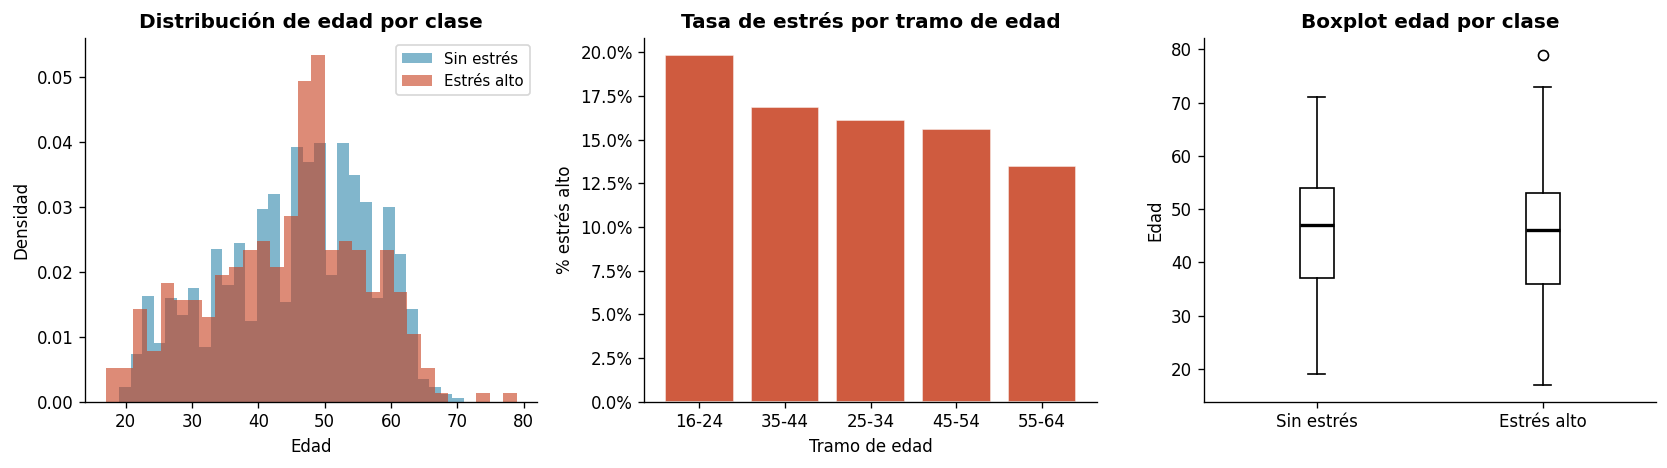

Edad media — sin estrés: 45.5  |  estrés alto: 44.3
Mann-Whitney: U=391292, p=0.0667  → no significativa


In [4]:
target_age_dis(T0, T1, train)

Chi-cuadrado con sexo: U=1, p=0.229457607089906  -> no significativa
Chi-cuadrado con pais_nacimiento: U=120, p=1.1236640352254067e-26  -> diferencia significativa
Chi-cuadrado con nacionalidad: U=32, p=1.2650305833091555e-07  -> diferencia significativa


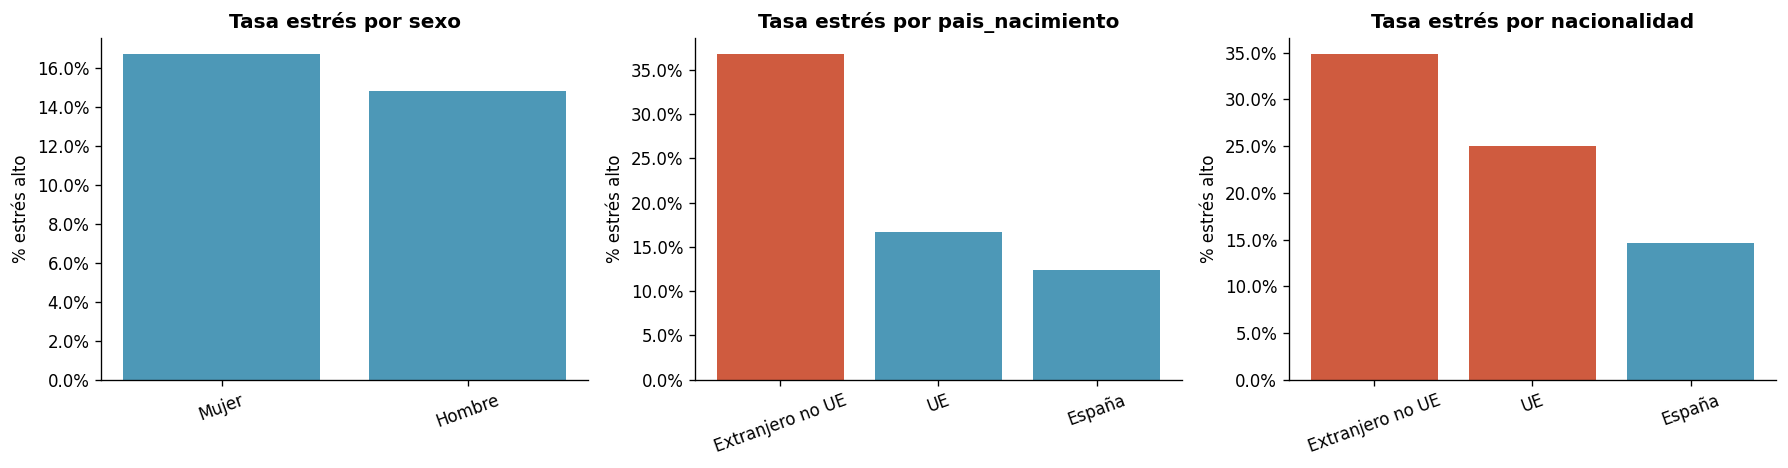

In [4]:
# Sexo, país de nacimiento y nacionalidad
cols_demo = [c for c in ['sexo', 'pais_nacimiento', 'nacionalidad']
             if c in train.columns]

target_vs_var_demo_dis(cols_demo, train)

## **4. Variables laborales**

La situación laboral es el grupo de variables de mayor poder predictivo esperado.
Se analizan tipo de contrato, jornada, horas trabajadas, precariedad e historial de desempleo.


Chi-cuadrado con tipo_contrato: U=2, p=0.5158184619983857  -> no significativa
Chi-cuadrado con jornada: U=21, p=4.7238038687142474e-06  -> diferencia significativa
Chi-cuadrado con precariedad_laboral: U=16, p=5.941048615053503e-05  -> diferencia significativa


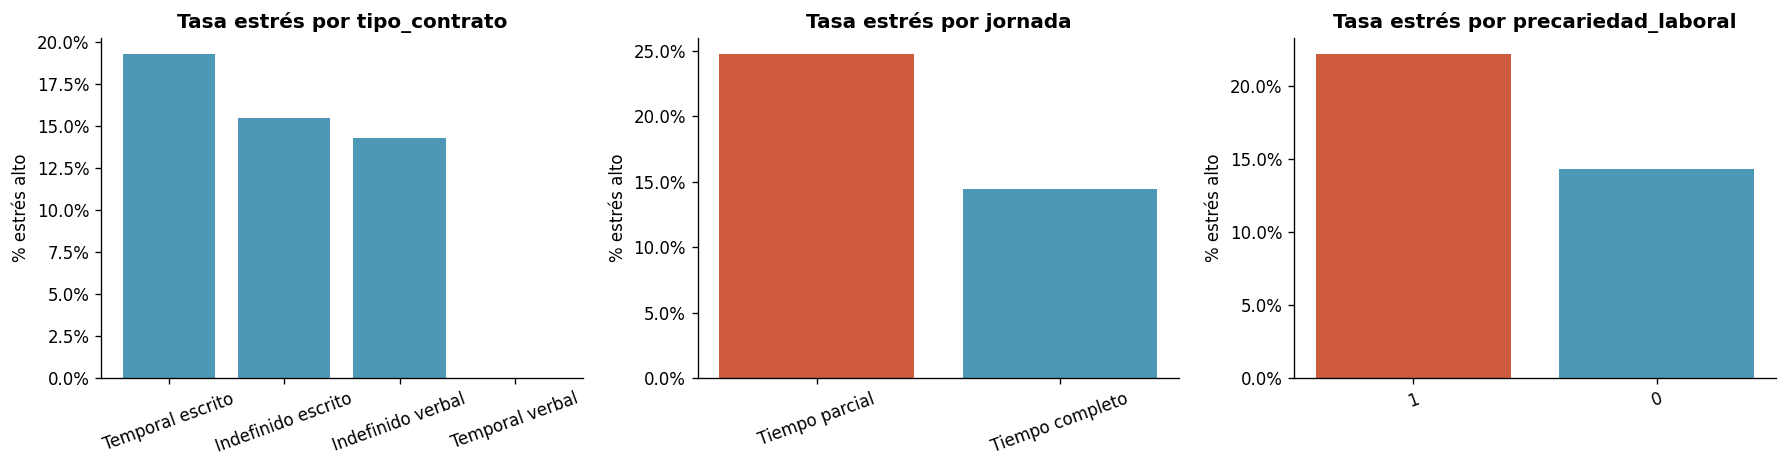

In [5]:
# Tasa de estrés por tipo de contrato y jornada
cols_lab = [c for c in ['tipo_contrato', 'jornada', 'precariedad_laboral']
            if c in train.columns]

target_vs_var_lab(cols_lab, train)

Mann-Whitney: U=371254, p=0.2093  -> no significativa
Mann-Whitney: U=387354, p=0.0245  -> diferencia significativa


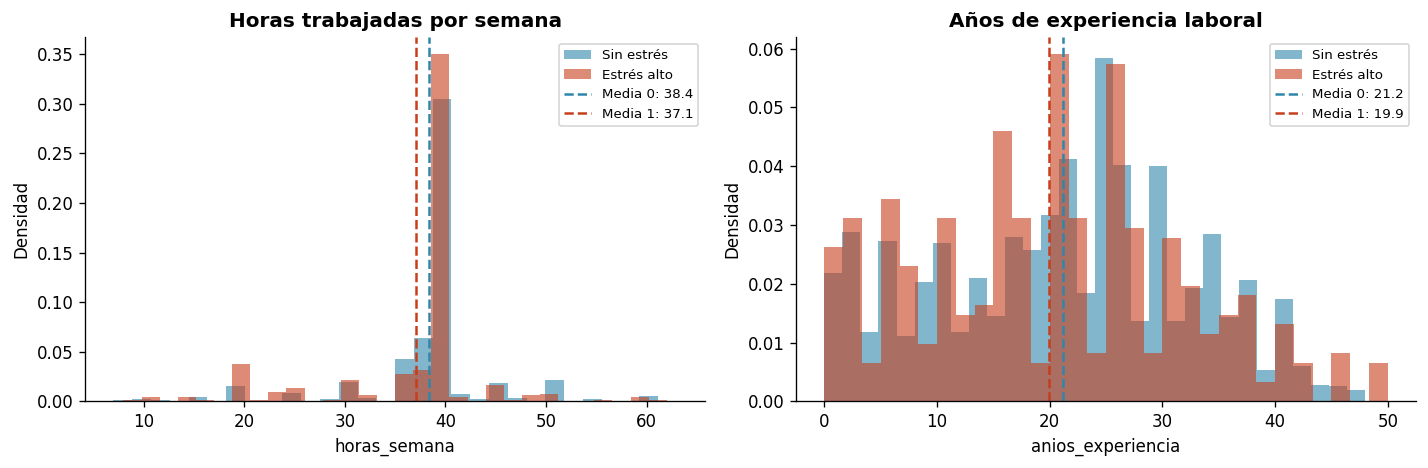

In [6]:
target_vs_hours_exp(train, T0, T1)

In [ ]:
# ── Desempleo: meses en referencia y 5 años ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, titulo in zip(axes,
    ['meses_desempleo_ref', 'meses_desempleo_5anios'],
    ['Meses en desempleo (año ref.)', 'Meses en desempleo (últimos 5 años)']):
    if col not in train.columns: continue
    datos0 = T0[col].dropna()
    datos1 = T1[col].dropna()
    ax.hist(datos0, bins=30, color=C0, alpha=0.6, label='Sin estrés', density=True)
    ax.hist(datos1, bins=30, color=C1, alpha=0.6, label='Estrés alto', density=True)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Meses')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_desempleo.png', bbox_inches='tight')
plt.show()

for col in ['meses_desempleo_ref', 'meses_desempleo_5anios']:
    if col not in train.columns: continue
    m0 = wmean(T0[col].dropna(), P0[T0[col].notna()])
    m1 = wmean(T1[col].dropna(), P1[T1[col].notna()])
    print(f'{col}: media sin estrés={m0:.1f}  |  media estrés alto={m1:.1f}')


In [ ]:
# ── Nivel de estudios ────────────────────────────────────────────────────
if 'nivel_estudios' in train.columns:
    orden = ['Hasta primaria', 'Secundaria 1a etapa', 'Post-secundaria',
             'Superior universitario', 'Master/Doctorado']
    cats_ok = [c for c in orden if c in train['nivel_estudios'].dropna().unique()]
    if not cats_ok:
        cats_ok = sorted(train['nivel_estudios'].dropna().unique())

    tasas = {str(c): wfreq(train.loc[train['nivel_estudios']==c, 'estres_financiero_alto'],
                           1, PESO[train['nivel_estudios']==c]) * 100
             for c in cats_ok}

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(list(tasas.keys()), list(tasas.values()), color=C1, alpha=0.85)
    ax.set_title('Tasa de estrés por nivel de estudios (ponderada)', fontweight='bold')
    ax.set_ylabel('% estrés alto')
    ax.tick_params(axis='x', rotation=15)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    plt.tight_layout()
    plt.savefig('eda_estudios.png', bbox_inches='tight')
    plt.show()


---
## EDA.5 Variables de renta

Las variables de renta son las de mayor potencial predictivo y presentan alta asimetría.
Se analiza la distribución, la separación entre clases y la correlación con el target.


In [ ]:
COLS_RENTA = [c for c in [
    'renta_neta_salarial', 'renta_neta_hogar',
    'renta_hogar_per_capita', 'renta_no_monetaria_salarial',
] if c in train.columns]

fig, axes = plt.subplots(2, len(COLS_RENTA), figsize=(4*len(COLS_RENTA), 7))
if len(COLS_RENTA) == 1: axes = axes.reshape(-1,1)

for j, col in enumerate(COLS_RENTA):
    # Fila 0: KDE por clase
    d0 = T0[col].dropna()
    d1 = T1[col].dropna()
    axes[0, j].hist(d0, bins=40, color=C0, alpha=0.6, density=True, label='Sin estrés')
    axes[0, j].hist(d1, bins=40, color=C1, alpha=0.6, density=True, label='Estrés alto')
    m0 = wmean(d0, P0[T0[col].notna()])
    m1 = wmean(d1, P1[T1[col].notna()])
    axes[0, j].axvline(m0, color=C0, linestyle='--', lw=1.5)
    axes[0, j].axvline(m1, color=C1, linestyle='--', lw=1.5)
    axes[0, j].set_title(f'{col}\nskew={d0._append(d1).skew():.1f}', fontsize=9, fontweight='bold')
    axes[0, j].set_ylabel('Densidad' if j==0 else '')
    axes[0, j].legend(fontsize=7)

    # Fila 1: log1p
    d0l = np.log1p(d0.clip(lower=0))
    d1l = np.log1p(d1.clip(lower=0))
    axes[1, j].hist(d0l, bins=40, color=C0, alpha=0.6, density=True)
    axes[1, j].hist(d1l, bins=40, color=C1, alpha=0.6, density=True)
    axes[1, j].set_title(f'log1p({col})', fontsize=9)
    axes[1, j].set_ylabel('Densidad (log)' if j==0 else '')

plt.suptitle('Distribución de rentas por clase — original vs log1p', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_rentas.png', bbox_inches='tight')
plt.show()

print('Medias ponderadas (€):')
for col in COLS_RENTA:
    if col not in train.columns: continue
    m0 = wmean(T0[col].dropna(), P0[T0[col].notna()])
    m1 = wmean(T1[col].dropna(), P1[T1[col].notna()])
    print(f'  {col:<35} sin estrés: {m0:>9,.0f}€  |  estrés alto: {m1:>9,.0f}€  |  ratio: {m0/m1:.2f}x')


In [ ]:
# ── Percentiles de renta por clase ───────────────────────────────────────
col = 'renta_neta_salarial'
if col in train.columns:
    pcts = [10, 25, 50, 75, 90]
    df_pct = pd.DataFrame({
        'Percentil': [f'P{p}' for p in pcts],
        'Sin estrés': [T0[col].dropna().quantile(p/100) for p in pcts],
        'Estrés alto': [T1[col].dropna().quantile(p/100) for p in pcts],
    })
    print('Percentiles de renta neta salarial por clase (€):')
    print(df_pct.to_string(index=False, float_format=lambda x: f'{x:,.0f}'))


---
## EDA.6 Variables de vivienda y cargas


In [ ]:
# ── Régimen de tenencia y tipo de vivienda ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['regimen_tenencia', 'tipo_vivienda', 'tipo_hogar']):
    if col not in train.columns:
        axes[i].set_visible(False)
        continue
    cats = train[col].dropna().unique()
    tasas = {str(c): wfreq(train.loc[train[col]==c, 'estres_financiero_alto'],
                           1, PESO[train[col]==c]) * 100
             for c in cats}
    tasas = dict(sorted(tasas.items(), key=lambda x: x[1], reverse=True))
    axes[i].bar(list(tasas.keys()), list(tasas.values()), color=C1, alpha=0.85)
    axes[i].set_title(f'Tasa estrés por {col}', fontweight='bold')
    axes[i].set_ylabel('% estrés alto')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.savefig('eda_vivienda.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── Ratio de carga de vivienda ───────────────────────────────────────────
col = 'ratio_carga_vivienda'
if col in train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(T0[col].dropna(), bins=40, color=C0, alpha=0.6, density=True, label='Sin estrés')
    axes[0].hist(T1[col].dropna(), bins=40, color=C1, alpha=0.6, density=True, label='Estrés alto')
    axes[0].axvline(0.30, color='black', linestyle='--', lw=1.5, label='30% (sobrecarga)')
    axes[0].set_title('Ratio carga vivienda / renta salarial', fontweight='bold')
    axes[0].set_xlabel('Ratio')
    axes[0].legend(fontsize=9)

    # Tasa de estrés según sobrecarga
    train['_sobrecarga'] = (train[col] > 0.30).map({True: '>30% (sobrecarga)', False: '≤30%'})
    tasas_sob = train.groupby('_sobrecarga').apply(
        lambda g: wfreq(g['estres_financiero_alto'], 1, PESO[g.index]) * 100
    )
    axes[1].bar(tasas_sob.index, tasas_sob.values, color=[C1, C0], alpha=0.85)
    axes[1].set_title('Tasa de estrés según sobrecarga de vivienda', fontweight='bold')
    axes[1].set_ylabel('% estrés alto (ponderado)')
    axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    train = train.drop(columns=['_sobrecarga'])

    plt.tight_layout()
    plt.savefig('eda_ratio_vivienda.png', bbox_inches='tight')
    plt.show()

    n_sob = (train[col] > 0.30).sum()
    print(f'Personas en train con sobrecarga (>30%): {n_sob} ({n_sob/len(train)*100:.1f}%)')


---
## EDA.7 Variables de privación material y salud


In [ ]:
# ── Privación material: tasa de estrés por cada indicador ───────────────
COLS_PRIVACION = [c for c in [
    'puede_vacaciones', 'puede_proteina_2dias',
    'puede_calefaccion_invierno', 'puede_sustituir_muebles',
] if c in train.columns]

if COLS_PRIVACION:
    tasas_priv = {}
    for col in COLS_PRIVACION:
        for val in train[col].dropna().unique():
            mask = train[col] == val
            lbl = f'{col.replace("puede_","")}\n({val})'
            tasas_priv[lbl] = wfreq(train.loc[mask,'estres_financiero_alto'],1,PESO[mask])*100

    tasas_priv = dict(sorted(tasas_priv.items(), key=lambda x: x[1], reverse=True))

    fig, ax = plt.subplots(figsize=(12, 4))
    colores = [C1 if 'No' in k else C0 for k in tasas_priv.keys()]
    bars = ax.bar(range(len(tasas_priv)), list(tasas_priv.values()), color=colores, alpha=0.85)
    ax.bar_label(bars, [f'{v:.1f}%' for v in tasas_priv.values()], padding=3, fontsize=7)
    ax.set_xticks(range(len(tasas_priv)))
    ax.set_xticklabels(list(tasas_priv.keys()), rotation=30, ha='right', fontsize=8)
    ax.set_title('Tasa de estrés por indicador de privación material', fontweight='bold')
    ax.set_ylabel('% estrés alto (ponderado)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    plt.tight_layout()
    plt.savefig('eda_privacion.png', bbox_inches='tight')
    plt.show()


In [ ]:
# ── Salud: estado de salud y limitación de actividad ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, titulo in zip(axes,
    ['estado_salud', 'limitacion_actividad'],
    ['Estado de salud percibido', 'Limitación de actividad']):
    if col not in train.columns:
        ax.set_visible(False)
        continue
    cats = sorted(train[col].dropna().unique())
    tasas = [wfreq(train.loc[train[col]==c,'estres_financiero_alto'],1,PESO[train[col]==c])*100
             for c in cats]
    ax.bar([str(c) for c in cats], tasas, color=C_NEUTRAL, alpha=0.85)
    ax.set_title(f'Tasa estrés por {titulo}', fontweight='bold')
    ax.set_ylabel('% estrés alto')
    ax.tick_params(axis='x', rotation=15)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.savefig('eda_salud.png', bbox_inches='tight')
plt.show()


---
## EDA.8 Variables de dinámica de ingresos


In [ ]:
# ── Cambio e expectativa de ingresos ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, titulo in zip(axes,
    ['cambio_ingresos_12m', 'expectativa_ingresos_12m'],
    ['Cambio ingresos últimos 12 meses', 'Expectativa ingresos próximos 12 meses']):
    if col not in train.columns:
        ax.set_visible(False)
        continue
    cats = train[col].dropna().unique()
    tasas = {str(c): wfreq(train.loc[train[col]==c,'estres_financiero_alto'],
                           1, PESO[train[col]==c]) * 100
             for c in cats}
    tasas = dict(sorted(tasas.items(), key=lambda x: x[1], reverse=True))
    ax.bar(list(tasas.keys()), list(tasas.values()), color=C1, alpha=0.85)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('% estrés alto')
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.savefig('eda_dinamica_ingresos.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── Motivos de cambio de ingresos ────────────────────────────────────────
for col in ['motivo_aumento_ingresos', 'motivo_disminucion_ingresos']:
    if col not in train.columns: continue
    cats = train[col].dropna().unique()
    tasas = {str(c): wfreq(train.loc[train[col]==c,'estres_financiero_alto'],
                           1, PESO[train[col]==c]) * 100
             for c in cats}
    tasas = dict(sorted(tasas.items(), key=lambda x: x[1], reverse=True))

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.bar(list(tasas.keys()), list(tasas.values()), color=C1, alpha=0.85)
    ax.set_title(f'Tasa estrés por {col}', fontweight='bold')
    ax.set_ylabel('% estrés alto')
    ax.tick_params(axis='x', rotation=25)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    plt.tight_layout()
    plt.savefig(f'eda_{col}.png', bbox_inches='tight')
    plt.show()


---
## EDA.9 Indicadores de pobreza INE

Estos indicadores están construidos directamente por el INE a partir de la encuesta.
Alta correlación esperada con el target, pero posible solapamiento semántico.


In [ ]:
COLS_POBREZA = [c for c in [
    'hogar_riesgo_pobreza', 'hogar_carencia_material',
    'arope_2020', 'arope_2030', 'carencia_material_social_severa',
    'baja_intensidad_laboral_2020',
] if c in train.columns]

if COLS_POBREZA:
    tasas_pob = {}
    n_vars = len(COLS_POBREZA)
    for col in COLS_POBREZA:
        for val in ['Sí', 'No', 1.0, 0.0, '1', '0']:
            if val in train[col].values or val == train[col].dropna().unique()[0]:
                pass
        # Tasa de estrés cuando el indicador está activo
        val_pos = train[col].dropna().unique()
        for v in val_pos:
            mask = train[col] == v
            tasas_pob[f'{col}\n={v}'] = wfreq(
                train.loc[mask,'estres_financiero_alto'], 1, PESO[mask]) * 100

    tasas_pob = dict(sorted(tasas_pob.items(), key=lambda x: x[1], reverse=True)[:16])

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.bar(range(len(tasas_pob)), list(tasas_pob.values()), color=C_NEUTRAL, alpha=0.85)
    ax.set_xticks(range(len(tasas_pob)))
    ax.set_xticklabels(list(tasas_pob.keys()), rotation=35, ha='right', fontsize=8)
    ax.set_title('Tasa de estrés por indicador de pobreza INE', fontweight='bold')
    ax.set_ylabel('% estrés alto (ponderado)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    plt.tight_layout()
    plt.savefig('eda_pobreza.png', bbox_inches='tight')
    plt.show()


---
## EDA.10 Correlaciones y multicolinealidad

Se usa correlación de Spearman (robusta a no normalidad y outliers) sobre las variables numéricas del train.
Se identifican pares altamente correlacionados (|ρ| > 0.7) que podrían causar problemas en modelos lineales.


In [ ]:
# ── Correlación de Spearman con el target ────────────────────────────────
X_num = train.select_dtypes(include='number').drop(columns=['estres_financiero_alto','peso_persona'], errors='ignore')

correlaciones = X_num.corrwith(train['estres_financiero_alto'], method='spearman').dropna()
correlaciones = correlaciones.sort_values(key=abs, ascending=False)

top_n = min(30, len(correlaciones))
top   = correlaciones.head(top_n)

fig, ax = plt.subplots(figsize=(8, max(5, top_n * 0.32)))
colores = [C1 if v > 0 else C0 for v in top.values]
bars = ax.barh(top.index[::-1], top.values[::-1], color=colores[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlación Spearman con estres_financiero_alto')
ax.set_title(f'Top {top_n} variables por correlación con el target', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlacion_target.png', bbox_inches='tight')
plt.show()

print('Top 15 correlaciones con el target:')
print(correlaciones.head(15).to_string())


In [ ]:
# ── Heatmap de correlaciones entre features (top 20 más correladas) ──────
top_cols = correlaciones.head(20).index.tolist()
top_cols = [c for c in top_cols if c in X_num.columns]

corr_matrix = X_num[top_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlaciones Spearman — top 20 features más correladas con el target',
             fontweight='bold')
plt.tight_layout()
plt.savefig('eda_heatmap_correlaciones.png', bbox_inches='tight')
plt.show()

# Pares con alta multicolinealidad
pares_altos = []
for i in range(len(corr_matrix)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.70:
            pares_altos.append((corr_matrix.index[i], corr_matrix.columns[j], round(r, 3)))

if pares_altos:
    print(f'Pares con |ρ| > 0.70 (multicolinealidad alta):')
    for a, b, r in sorted(pares_altos, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {a:<35} ↔  {b:<35} ρ={r}')
else:
    print('No hay pares con |ρ| > 0.70 entre las top 20 features.')


---
## EDA.11 Análisis de nulos en train

Los nulos del train son los que el Pipeline debe imputar ajustando parámetros **solo sobre train**.
Se analiza si el patrón de nulos es aleatorio o está relacionado con el target (MNAR).


In [ ]:
nulos_train = train.isnull().sum()
nulos_train = nulos_train[nulos_train > 0].sort_values(ascending=False)

print(f'Variables con nulos en train: {len(nulos_train)}')
print()

# Para cada variable con nulos: ¿la tasa de estrés difiere entre observados y nulos?
print(f'{"Variable":<40} {"N nulos":>8}  {"%":>5}  Tasa estrés obs  Tasa estrés (resto)')
print('-' * 95)
for col, n in nulos_train.items():
    pct = n / len(train) * 100
    mask_null = train[col].isna()
    tasa_obs  = wfreq(train.loc[~mask_null,'estres_financiero_alto'], 1, PESO[~mask_null]) * 100
    tasa_null = wfreq(train.loc[mask_null, 'estres_financiero_alto'], 1, PESO[mask_null])  * 100 if mask_null.sum() > 5 else np.nan
    flag_mnar = '⚠ MNAR?' if (not np.isnan(tasa_null) and abs(tasa_obs - tasa_null) > 10) else ''
    print(f'  {col:<38} {n:>8,}  {pct:>4.1f}%  {tasa_obs:>15.1f}%  {tasa_null if not np.isnan(tasa_null) else "n/a":>18}  {flag_mnar}')


---
## EDA.12 Insights clave para la memoria del TFM

Resumen ejecutivo de los hallazgos del EDA con implicaciones para el modelado.


In [ ]:
# ── Tabla resumen: diferencias entre clases en variables clave ───────────
VARS_RESUMEN = [c for c in [
    'renta_neta_salarial', 'renta_neta_hogar', 'renta_hogar_per_capita',
    'ratio_carga_vivienda', 'horas_semana', 'anios_experiencia',
    'meses_desempleo_ref', 'meses_desempleo_5anios',
] if c in train.columns]

filas = []
for col in VARS_RESUMEN:
    m0 = wmean(T0[col].dropna(), P0[T0[col].notna()])
    m1 = wmean(T1[col].dropna(), P1[T1[col].notna()])
    stat, p = stats.mannwhitneyu(T0[col].dropna(), T1[col].dropna(), alternative='two-sided')
    filas.append({
        'Variable': col,
        'Media sin estrés': round(m0, 2),
        'Media estrés alto': round(m1, 2),
        'Ratio (0/1)': round(m0/m1, 2) if m1 != 0 else np.nan,
        'p-valor (MWU)': round(p, 4),
        'Sig.': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')),
    })

print(pd.DataFrame(filas).to_string(index=False))


In [ ]:
# ── Porcentaje de varianza explicada por las top 5 features ─────────────
X_num_clean = X_num.dropna(axis=1, thresh=int(len(train)*0.80))
X_num_imp = X_num_clean.fillna(X_num_clean.median())

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

y_eda = train['estres_financiero_alto'].astype(int)
clf_quick = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)
clf_quick.fit(X_num_imp, y_eda)

imp = pd.Series(clf_quick.feature_importances_, index=X_num_imp.columns)
imp = imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp.index[::-1], imp.values[::-1], color=C_NEUTRAL, alpha=0.85)
ax.set_xlabel('Importancia (GBM rápido, solo variables numéricas)')
ax.set_title('Importancia preliminar de features — orientativa para el modelado',
             fontweight='bold')
plt.tight_layout()
plt.savefig('eda_importancia_preliminar.png', bbox_inches='tight')
plt.show()

print('Top 10 features por importancia preliminar (GBM, numéricas):')
print(imp.head(10).to_string())


---
## Resumen de insights

A completar con los resultados reales tras ejecutar el notebook. Plantilla de hallazgos:

### 📊 Perfil del asalariado con estrés financiero alto

| Dimensión | Hallazgo |
|-----------|----------|
| Renta | Renta media ~X€ vs ~Y€ en clase 0 (ratio Z) |
| Empleo | Mayor tasa en contratos temporales y jornada parcial |
| Vivienda | Mayor proporción en alquiler; ratio carga vivienda elevado |
| Privación | Fuerte asociación con incapacidad para vacaciones y proteína |
| Demografía | [Completar con resultados] |

### 🔑 Implicaciones para el modelado

1. **Variables de renta**: aplicar `log1p` en el Pipeline (skew > 2.5 confirmado)  
2. **Desbalanceo 1:5**: confirmar `class_weight='balanced'` como estrategia principal  
3. **Multicolinealidad**: los pares renta_neta_hogar ↔ renta_hogar_per_capita requieren atención en modelos lineales  
4. **Nulos MNAR**: [identificar si hay variables con patrón de nulos relacionado con el target]  
5. **Features más informativas preliminarmente**: [completar con importancias del GBM rápido]
